In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Section A – Data Exploration

In [73]:
#1 Loading the Dataset
df=pd.read_csv("/content/heart.csv")

#2 Display First 5 Rows
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [74]:
#3 Using info and describe to summarise data
df.info()
df.describe()

#4 Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

print("Categorical Columns:",categorical_cols)
print("Numerical Columns:",numerical_cols)

#5: Finding Missing Values
print("Missing Values:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')
Numerical Columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpe

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Section B – Data Cleaning

In [75]:
#1 Verify whether the dataset contains null values.
print("Null Values:")
df.isnull().sum()

#2 Handle missing values if present
df=df.fillna(df.mean(numeric_only=True))

#3 Confirm that the dataset is clean
print("Null Values After Cleaning:")
df.isnull().sum()

Null Values:
Null Values After Cleaning:


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Section C – Statistical Analysis

In [76]:
sel_cols=["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]
df=df[sel_cols]
#1 Mean
mean_val=df[sel_cols].mean()
print("Mean:")
mean_val

Mean:


,0
Age,53.510893
RestingBP,132.396514
Cholesterol,198.799564
MaxHR,136.809368
Oldpeak,0.887364


In [77]:
#2 Calculate Standard Deviation
std_va=df[sel_cols].std()
print("Standard Deviation:")
std_val

Standard Deviation:


,0
Age,9.432617
RestingBP,18.514154
Cholesterol,109.384145
MaxHR,25.460334
Oldpeak,1.066570


In [78]:
#3 Calculate Skewness
skew_val=df[sel_cols].skew()
print("Skewness:")
skew_val

Skewness:


,0
Age,-0.195933
RestingBP,0.179839
Cholesterol,-0.610086
MaxHR,-0.144359
Oldpeak,1.022872


Section D – Histogram Visualization


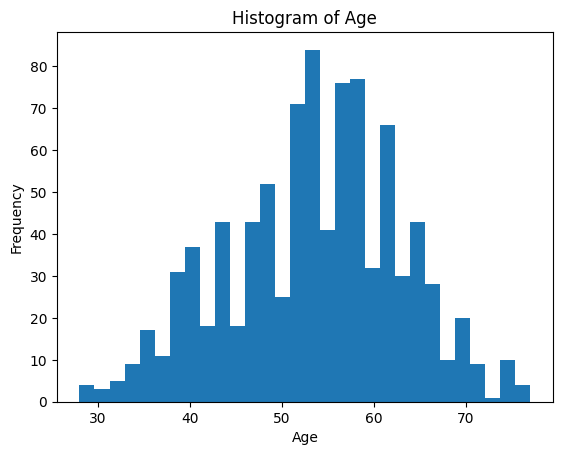

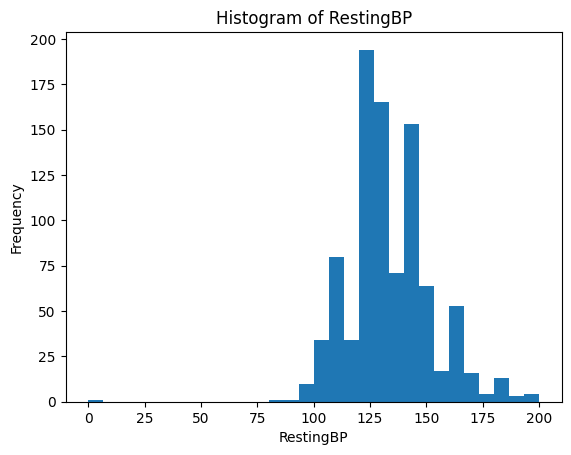

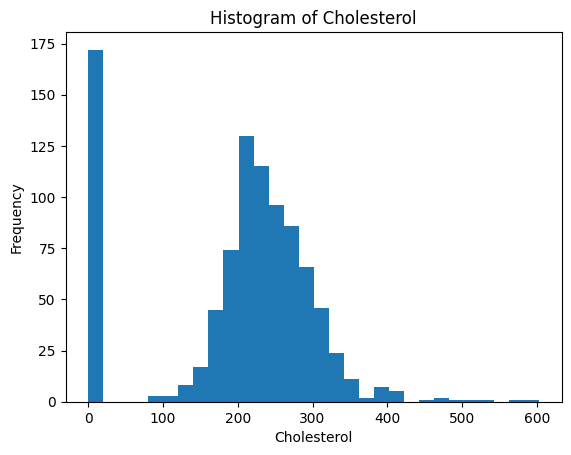

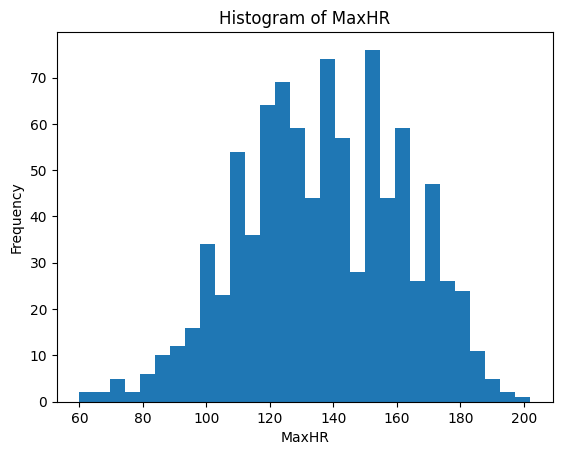

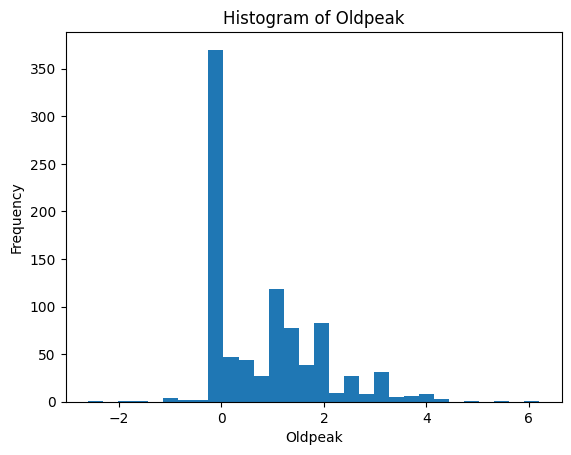

THE Columns Age, RestingBP, Cholesterol, MaxHR, and Oldpeak distributions can be visually analyzed by using the histograms


In [79]:
#1 Plot histogram for selected numerical columns
for col in sel_cols:
    plt.figure()
    plt.hist(df[col],bins=30)

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()
#2 Observe the distribution of each variable
print("THE Columns Age, RestingBP, Cholesterol, MaxHR, and Oldpeak distributions can be visually analyzed by using the histograms")

Section E – Boxplot Visualization

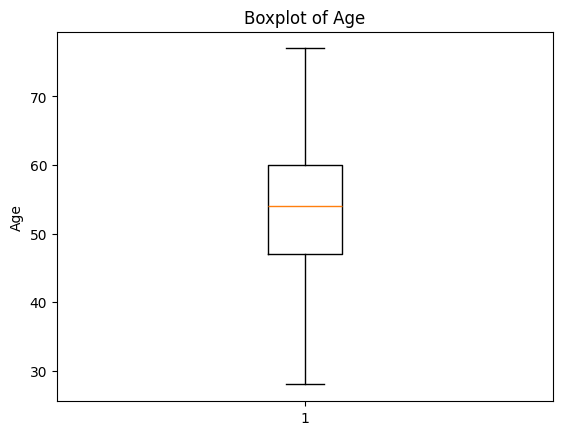

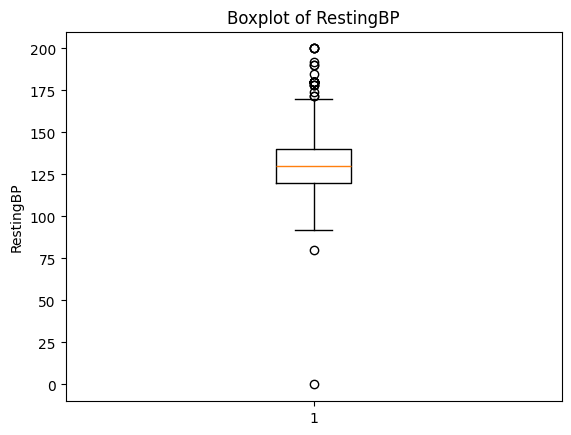

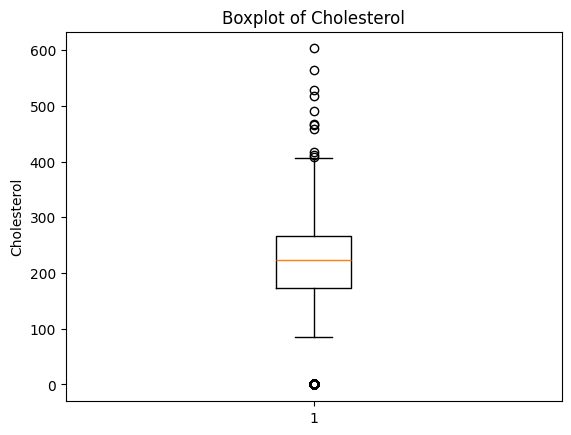

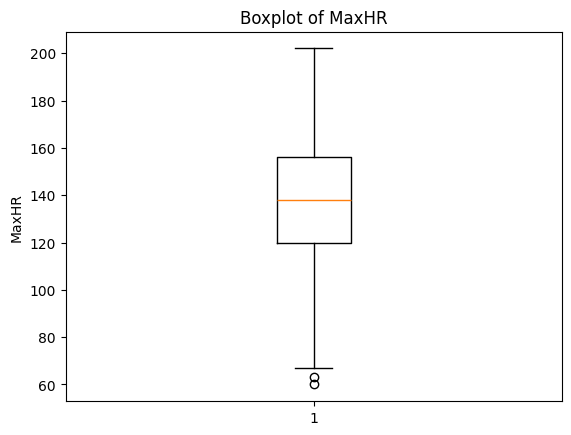

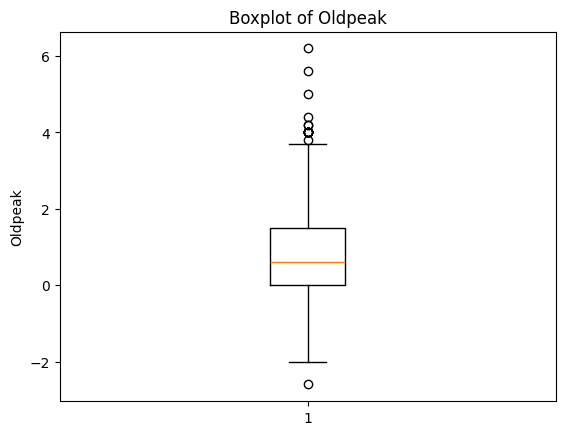

In [80]:
#1 Create boxplots for selected numerical columns
for col in sel_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [81]:
#2 Identify presence of outliers
outlier_cnt= {}
for col in sel_cols:

    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR= Q3 - Q1

    low=Q1 - 1.5 * IQR
    upp=Q3 + 1.5 * IQR
    outliers = df[(df[col] < low)|(df[col] > upp)]
    outlier_cnt[col] = len(outliers)
outlier_cnt

{'Age': 0, 'RestingBP': 28, 'Cholesterol': 183, 'MaxHR': 2, 'Oldpeak': 16}

Section F – Interpretation

In [82]:
#1 Which variable has the highest mean value?
mean_val.idxmax()

'Cholesterol'

In [83]:
#2 Which variable shows the highest standard deviation?
std_val.idxmax()

'Cholesterol'

In [84]:
#3 Which variable appears most skewed?
print("Variable with Most Skewness:", skew_val.abs().idxmax())

Variable with Most Skewness: Oldpeak


In [85]:
#4 Which variable shows maximum outliers?
max_outlier_variable = max(outlier_cnt, key=outlier_cnt.get)
max_outlier_variable

'Cholesterol'

In [86]:
#5 Write a short conclusion about the dataset distribution

#Central Tendency: RestingBP has the highest mean, while Oldpeak has the lowest.
#Variability: Cholesterol shows the most variability, and Oldpeak the least.
#Skewness: Oldpeak is positively skewed, indicating a tail to the right. Cholesterol is negatively skewed.
##Outliers: Cholesterol has the highest number of outliers, followed by RestingBP and Oldpeak, suggesting significant extreme values in these features. Age, MaxHR, and HeartDisease have very few or no outliers.
#Overall: Cholesterol and RestingBP exhibit considerable variability and outliers.